Saving WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg to WhatsApp Image 2026-09-09 at 20.02.43 (2) (1).jpeg


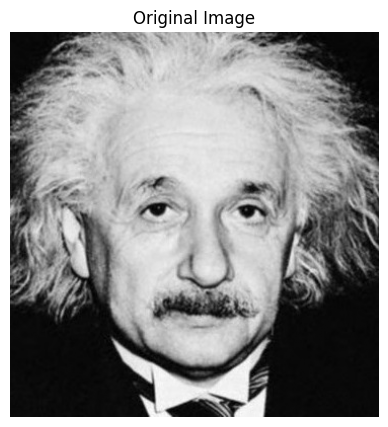

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read as grayscale
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [14]:
sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

In [15]:
sobel_filter2d = cv2.filter2D(
    img,
    cv2.CV_64F,
    sobel_x
)

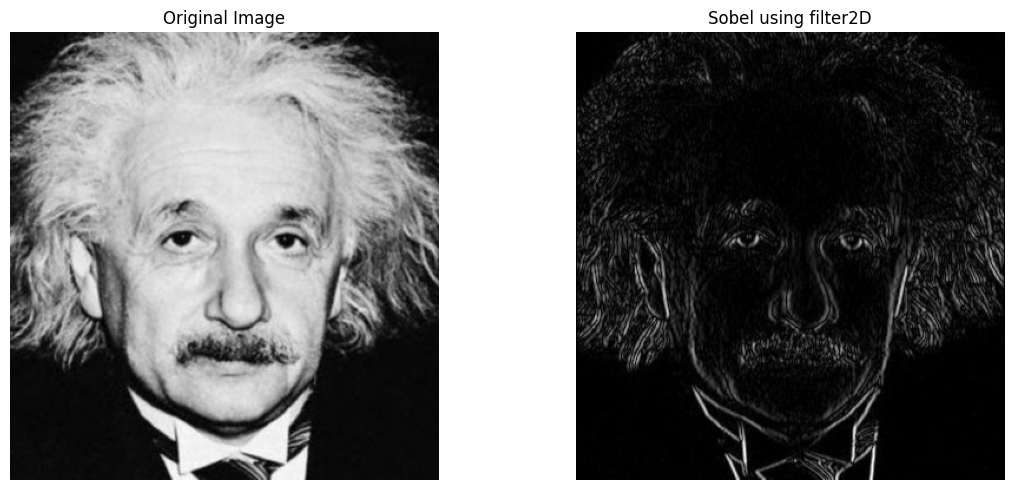

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.abs(sobel_filter2d), cmap='gray')
plt.title("Sobel using filter2D")
plt.axis("off")

plt.tight_layout()
plt.show()

b)

In [17]:
def my_sobel_filter(img, kernel):

    height, width = img.shape

    # Pad image by 1 pixel
    padded = np.pad(
        img,
        ((1, 1), (1, 1)),
        mode='constant'
    )

    output = np.zeros(
        (height, width),
        dtype=np.float64
    )

    # Move kernel across image
    for i in range(height):
        for j in range(width):

            region = padded[i:i+3, j:j+3]

            output[i, j] = np.sum(
                region * kernel
            )

    return output

In [18]:
sobel_manual = my_sobel_filter(
    img,
    sobel_x
)

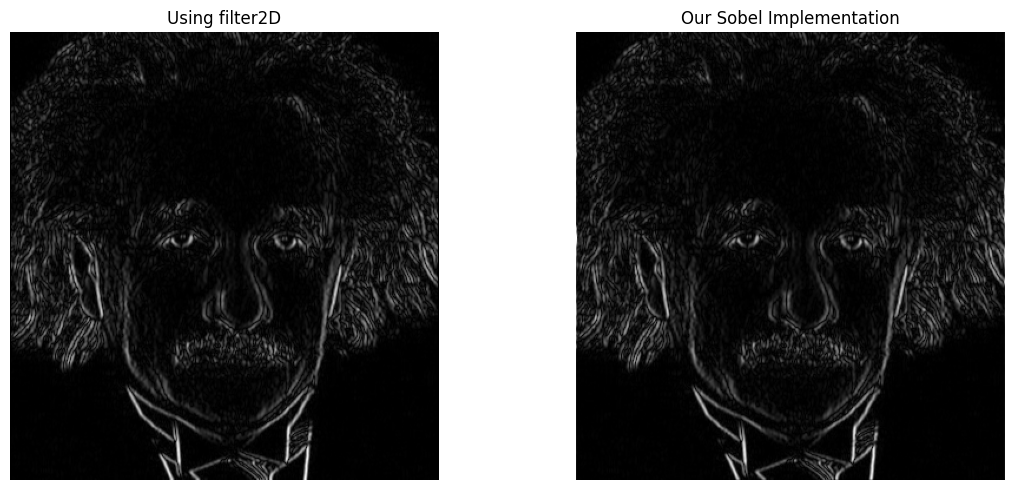

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.abs(sobel_filter2d), cmap='gray')
plt.title("Using filter2D")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.abs(sobel_manual), cmap='gray')
plt.title("Our Sobel Implementation")
plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
print(
    "Maximum difference:",
    np.max(np.abs(sobel_filter2d - sobel_manual))
)

Maximum difference: 762.0


c)

In [21]:
vertical_kernel = np.array([
    [1],
    [2],
    [1]
], dtype=np.float32)

horizontal_kernel = np.array([
    [1, 0, -1]
], dtype=np.float32)

In [22]:
temp = cv2.filter2D(
    img,
    cv2.CV_64F,
    vertical_kernel
)

In [23]:
sobel_separable = cv2.filter2D(
    temp,
    cv2.CV_64F,
    horizontal_kernel
)

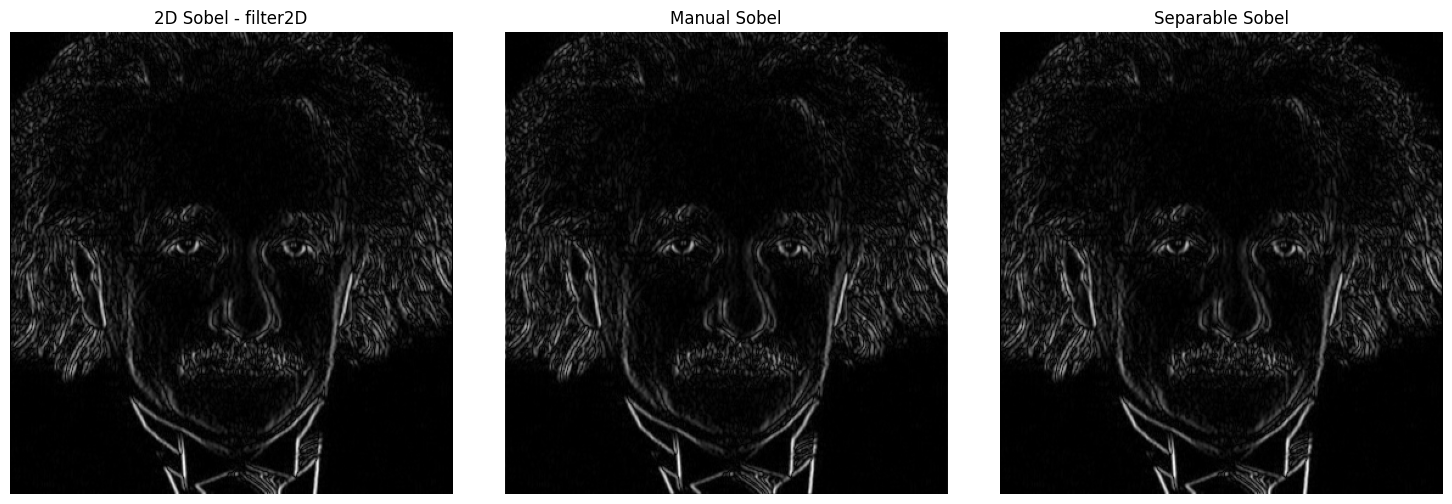

In [24]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(np.abs(sobel_filter2d), cmap='gray')
plt.title("2D Sobel - filter2D")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.abs(sobel_manual), cmap='gray')
plt.title("Manual Sobel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(sobel_separable), cmap='gray')
plt.title("Separable Sobel")
plt.axis("off")

plt.tight_layout()
plt.show()